In [6]:
import pandas as pd
import torch
import json

edges_df = pd.read_csv('./git_web_ml/musae_git_edges.csv')
edge_index = torch.tensor(edges_df[['id_1', 'id_2']].values.T, dtype=torch.long)

with open('./git_web_ml/musae_git_features.json', 'r') as f:
    node_features_dict = json.load(f)

max_feats = max([len(item) for item in list(node_features_dict.values())])

l = []
for item in node_features_dict.values():
    if len(item) < max_feats:
        l.append(item + [0.] * (max_feats - len(item)))
    else:
        l.append(item)
        
node_features = torch.tensor(l, dtype=torch.float)

target_df = pd.read_csv('./git_web_ml/musae_git_target.csv')
node_labels = torch.tensor(target_df['ml_target'].values, dtype=torch.long)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
torch.set_default_device(device)

In [9]:
num_edges = edge_index.size(1)
edge_features = torch.zeros(num_edges, 64)

In [10]:
from torch_geometric.data import Data

data = Data(
    x=node_features,         
    edge_index=edge_index,   
    edge_attr=edge_features, 
    y=node_labels            
)

print(f"Number of nodes: {data.x.size(0)}")
print(f"Number of edges: {data.edge_index.size(1)}")
print(f"Node features shape: {data.x.shape}")
print(f"Edge features shape: {data.edge_attr.shape}")
print(f"Node labels shape: {data.y.shape}")

Number of nodes: 37700
Number of edges: 289003
Node features shape: torch.Size([37700, 42])
Edge features shape: torch.Size([289003, 64])
Node labels shape: torch.Size([37700])


In [11]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing

class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.0, final_activation=None):
        super().__init__()
        layers = []
        prev = in_channels
        for hidden in hidden_channels:
            layers.append(nn.Linear(prev, hidden))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev = hidden
        layers.append(nn.Linear(prev, out_channels))
        if final_activation is not None:
            layers.append(final_activation)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)
    
    def reset_parameters(self):
        for m in self.net:
            if hasattr(m, 'reset_parameters'):
                m.reset_parameters()

class RGINConv(MessagePassing):
    def __init__(
        self,
        mlp_dims_node: list,
        mlp_dims_edge: list,
        aggr: str = 'sum',
        dropout_rate: float = 0.0,
    ):
        super().__init__(node_dim=0, aggr=aggr)
        self.node_dimses = mlp_dims_node
        self.edge_dimses = mlp_dims_edge
        self.aggr = aggr
        self.dropout_rate = dropout_rate
        
        self.node_mlp = nn.ModuleList([
            MLP(mlp_dims_node[0], mlp_dims_node[1:-1], mlp_dims_node[-1],
                final_activation=None, dropout_rate=dropout_rate)
            for _ in range(mlp_dims_edge[-1])
        ])
        self.edge_mlp = MLP(mlp_dims_edge[0], mlp_dims_edge[1:-1], mlp_dims_edge[-1],
                            dropout_rate=dropout_rate, final_activation=None)
        self.reset_parameters()
        
    def reset_parameters(self):
        for m in self.node_mlp:
            m.reset_parameters()
        self.edge_mlp.reset_parameters()
        
    @classmethod
    def from_config(cls, config):
        return cls(**config)
        
    def get_config(self):
        return {
            'mlp_dims_node': self.node_dimses,
            'mlp_dims_edge': self.edge_dimses,
            'aggr': self.aggr,
            'dropout_rate': self.dropout_rate,
        }
    
    def forward(self, x: torch.Tensor, edge_index, edge_attr: torch.Tensor, edge_weight=None):
        edge_attr = self.edge_mlp(edge_attr).softmax(-1)
        if edge_weight is not None:
            edge_attr = edge_attr * edge_weight
        size = (x.size(0), x.size(0))
        out = torch.zeros(x.size(0), self.node_dimses[-1], device=x.device)

        for edge_idx in range(self.edge_dimses[-1]):
            h = self.propagate(edge_index, edge_attr=edge_attr, x=x, size=size, edge_idx=edge_idx)
            h2 = self.node_mlp[edge_idx](h)
            out = out + h2
        return out
    
    def message(self, x_j: torch.Tensor, edge_attr, edge_idx) -> torch.Tensor:
        return x_j * edge_attr[:, edge_idx].unsqueeze(-1)

In [12]:
import torch.nn as nn

class GNN6Layer(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(GNN6Layer, self).__init__()

        
        mlp_dims_node = [input_dim, hidden_dim, input_dim]
        mlp_dims_edge = [64, 32, 16]  
        
        
        # self.convs = nn.ModuleList([
        #     RGINConv(
        #         mlp_dims_node=mlp_dims_node,
        #         mlp_dims_edge=mlp_dims_edge,
        #         aggr='sum',  
        #         dropout_rate=dropout_rate
        #     ) for _ in range(6)
        # ])
        
        
        self.conv0 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )
        
        self.conv1 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )
        
        self.conv2 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )
        
        self.conv3 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )
        
        self.conv4 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )
        
        self.conv5 = RGINConv(
            mlp_dims_node=mlp_dims_node,
            mlp_dims_edge=mlp_dims_edge,
            aggr='sum',
            dropout_rate=dropout_rate
        )

        self.out_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, edge_attr):
        # for conv in self.convs:
        #     x = conv(x, edge_index, edge_attr)
        x = self.conv0(x, edge_index, edge_attr)
        x = self.conv1(x, edge_index, edge_attr)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.conv3(x, edge_index, edge_attr)
        x = self.conv4(x, edge_index, edge_attr)
        x = self.conv5(x, edge_index, edge_attr)
        out = self.out_layer(x)
        return out

    # def forward(self, x, edge_index, edge_attr):
    #     print(f"Before convs: x.shape = {x.shape}")

    #     for i, conv in enumerate(self.convs):
    #         print(f"Before conv {i}: x.shape = {x.shape}")
    #         x = conv(x, edge_index, edge_attr)
    #         print(f"After conv {i}: x.shape = {x.shape}")

    #     print(f"Before out_layer: x.shape = {x.shape}")
    #     out = self.out_layer(x)
    #     print(f"Output shape: {out.shape}")
    #     return out


In [19]:
model = GNN6Layer(input_dim=42, hidden_dim=42, output_dim=2, dropout_rate=0.1)
# output = model(node_features, edge_index, edge_features)

# print(output.shape)

In [14]:
edge_index.shape

torch.Size([2, 289003])

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 100

losses = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    output = model(node_features, edge_index, edge_features)

    # Compute loss
    loss = criterion(output, node_labels)
    losses.append(loss.item())

    # Backpropagation
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/100], Loss: 1831.8876
Epoch [2/100], Loss: 767.1742
Epoch [3/100], Loss: 2285.7598
Epoch [4/100], Loss: 838.3603
Epoch [5/100], Loss: 705.5640
Epoch [6/100], Loss: 650.1300
Epoch [7/100], Loss: 886.6490
Epoch [8/100], Loss: 968.9092
Epoch [9/100], Loss: 818.7881
Epoch [10/100], Loss: 668.7947
Epoch [11/100], Loss: 636.4290
Epoch [12/100], Loss: 749.6835
Epoch [13/100], Loss: 579.9267
Epoch [14/100], Loss: 1680.6211
Epoch [15/100], Loss: 963.6584
Epoch [16/100], Loss: 507.5384
Epoch [17/100], Loss: 466.2250
Epoch [18/100], Loss: 580.9269
Epoch [19/100], Loss: 389.9557
Epoch [20/100], Loss: 444.9503
Epoch [21/100], Loss: 431.5403
Epoch [22/100], Loss: 424.3932
Epoch [23/100], Loss: 377.0790
Epoch [24/100], Loss: 340.2133
Epoch [25/100], Loss: 430.9749
Epoch [26/100], Loss: 336.1115
Epoch [27/100], Loss: 350.1981
Epoch [28/100], Loss: 419.8691
Epoch [29/100], Loss: 312.6712
Epoch [30/100], Loss: 373.8021
Epoch [31/100], Loss: 265.8840
Epoch [32/100], Loss: 312.3968
Epoch [33/100]

In [21]:
import matplotlib.pyplot as plt

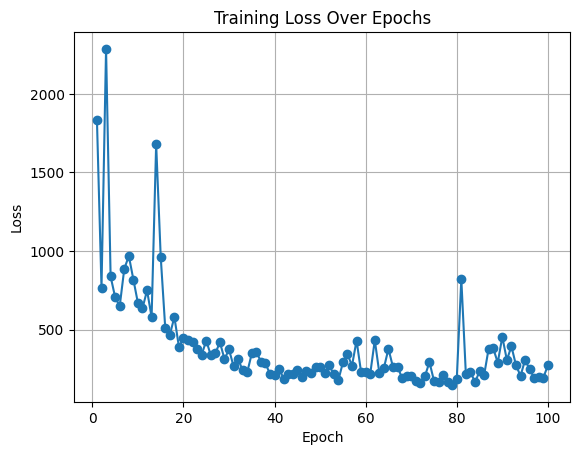

In [22]:
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()
plt.show()